In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import seaborn as sns
import numpy as np
import re

Extracted epochs: 10


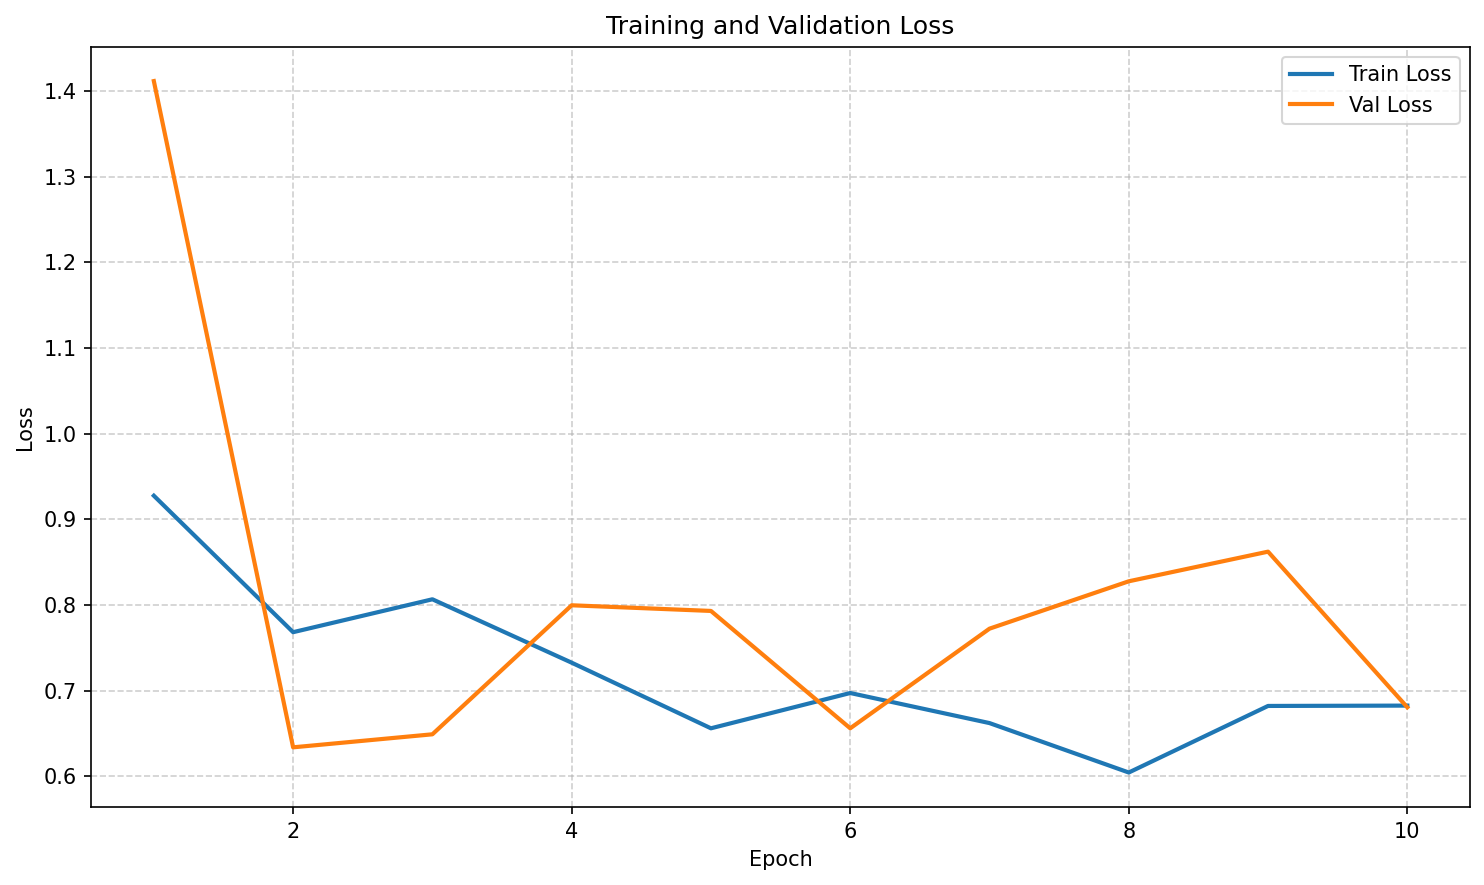

In [2]:
# Training and validation loss
log_path = "runs/run_20260216_105519/training_logs_8831684.log"

train_losses = []
val_losses = []

pattern = re.compile(r"Train Loss:\s*([0-9eE\.\-]+).*Val Loss:\s*([0-9eE\.\-]+)")

with open(log_path, "r") as f:
    for line in f:
        m = pattern.search(line)
        if m:
            train_losses.append(float(m.group(1)))
            val_losses.append(float(m.group(2)))

print("Extracted epochs:", len(train_losses))
if len(train_losses) == 0:
    raise ValueError("No Train/Val loss found. Check log format / pattern.")

epochs = list(range(1, len(train_losses) + 1))

plt.figure(figsize=(10, 6), dpi=150)
plt.plot(epochs, train_losses, label="Train Loss", linewidth=2)
plt.plot(epochs, val_losses, label="Val Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

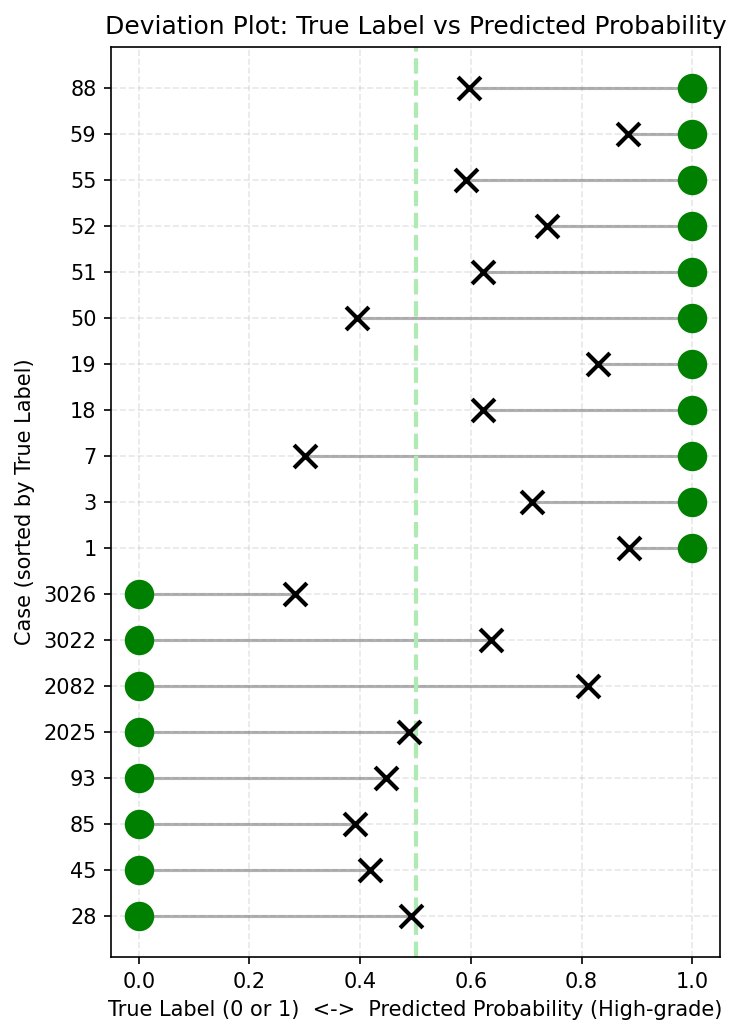

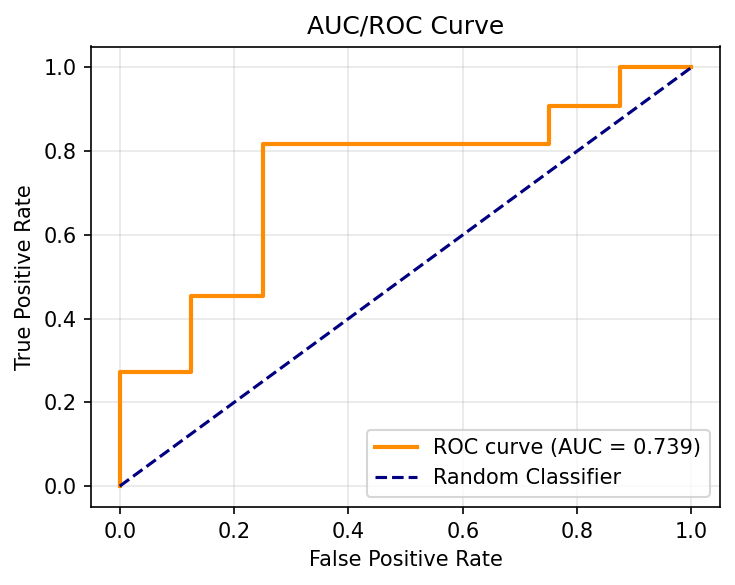


Computed AUC = 0.739


In [3]:
# Deviation plot (True label vs predicted probablity)
df = pd.read_csv("runs/run_20260216_105519/predictions.csv")

# Sort so true=0 cases appear first (optional but cleaner)
df_sorted = df.sort_values(["true_label", "case_id"]).reset_index(drop=True)
df_sorted["case_str"] = df_sorted["case_id"].astype(str)

# -----------------------------------------------------
# 1. Deviation Plot (True vs Probabilities)
# -----------------------------------------------------
plt.figure(figsize=(5,7), dpi=150)

for i, row in df_sorted.iterrows():
    # connecting line
    plt.plot(
        [row["true_label"], row["prob_high_grade"]],
        [i, i],
        color="gray",
        alpha=0.6,
        linewidth=1.5
    )

    # true label = large green circle
    plt.scatter(
        row["true_label"], i,
        color="green",
        s=200,
        marker="o",
        edgecolor="black",
        linewidth=0,
        zorder=3
    )

    # predicted probability = small black X
    plt.scatter(
        row["prob_high_grade"], i,
        color="black",
        s=120,
        marker="x",
        linewidths=2,
        zorder=4
    )

plt.yticks(range(len(df_sorted)), df_sorted["case_str"])
plt.axvline(0.5, color="#ADEBB3", linestyle="--", linewidth=2, label="Decision Threshold (0.5)")
plt.xlabel("True Label (0 or 1)  <->  Predicted Probability (High-grade)")
plt.ylabel("Case (sorted by True Label)")
plt.title("Deviation Plot: True Label vs Predicted Probability")
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

# -----------------------------------------------------
# 2. AUC / ROC Curve
# -----------------------------------------------------
fpr, tpr, thresholds = roc_curve(df["true_label"], df["prob_high_grade"])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4), dpi=150)
plt.plot(
    fpr, tpr,
    color='darkorange',
    lw=2,
    label=f'ROC curve (AUC = {roc_auc:.3f})'
)
plt.plot(
    [0, 1], [0, 1],
    color='navy',
    lw=1.5,
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC/ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nComputed AUC = {roc_auc:.3f}")

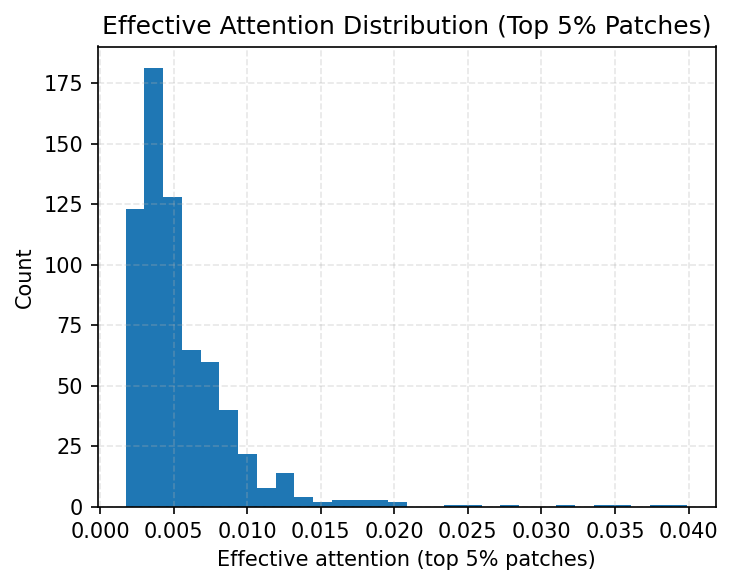

In [4]:
# Effective attention score distribution of patches
attn = pd.read_csv("runs/run_20260216_105519/attention_analysis/top_effective_patches_per_case_5.0pct.csv")

plt.figure(figsize=(5,4), dpi=150)
plt.hist(attn["effective_weight"], bins=30)
plt.xlabel("Effective attention (top 5% patches)")
plt.ylabel("Count")
plt.title("Effective Attention Distribution (Top 5% Patches)")
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

   case_id  stain  attention_weight
0     3026    h&e            0.2375
1     3026  melan            0.3388
2     3026  sox10            0.4237
3     2082    h&e            1.0000
4     3022    h&e            0.2029
cases: 19 rows: 55


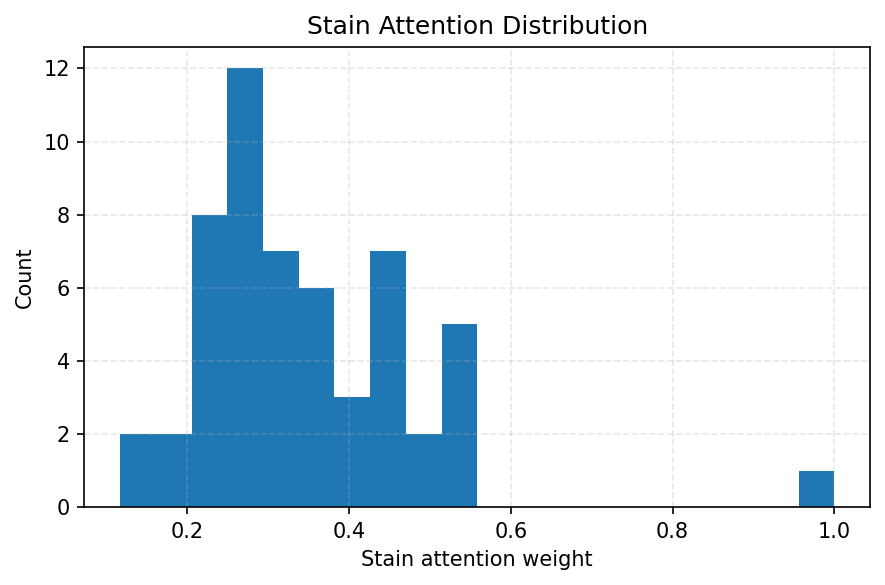

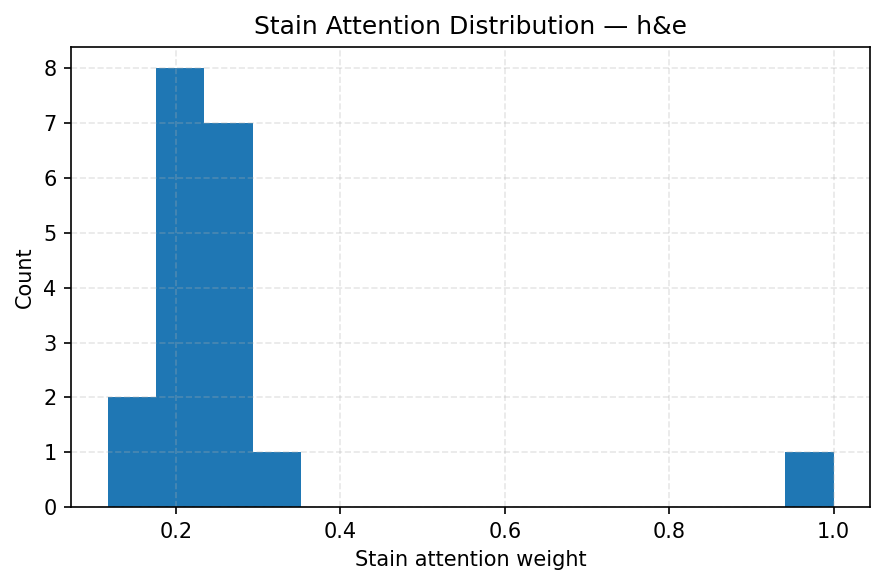

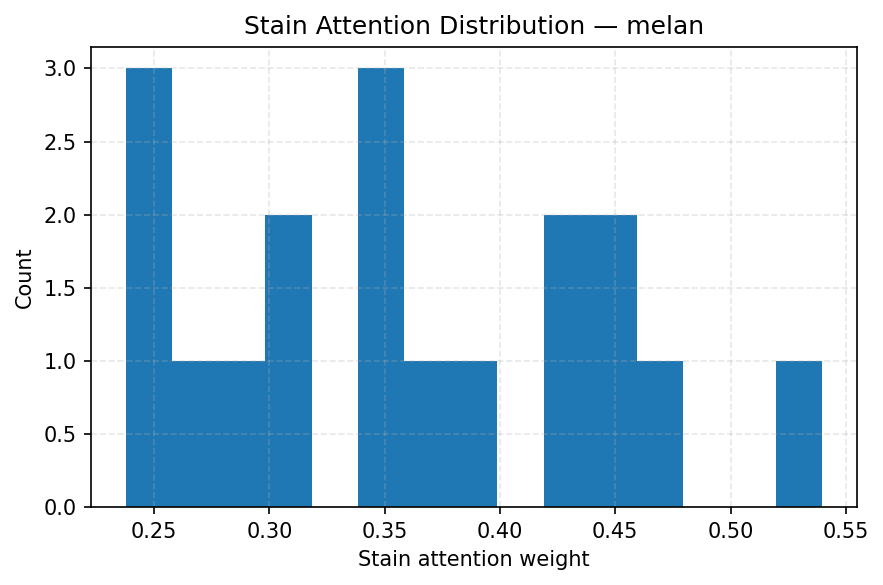

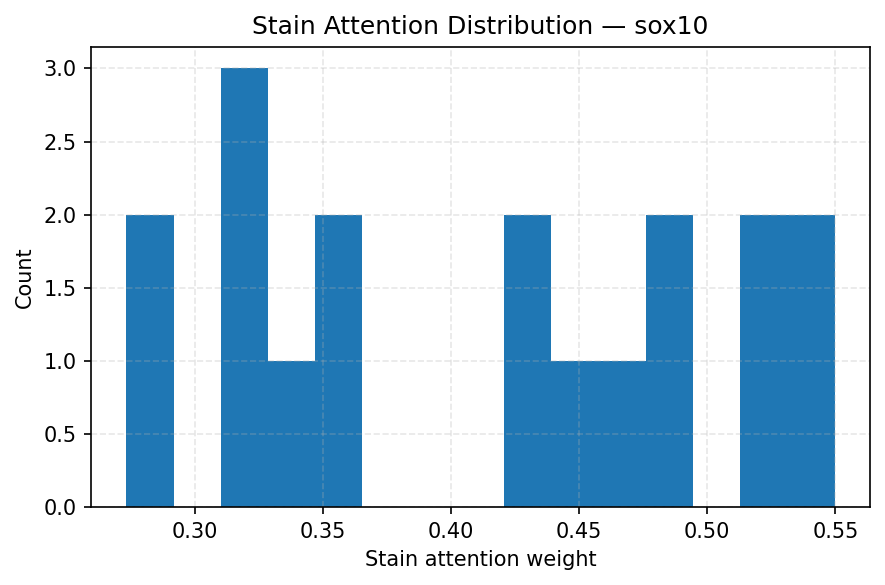

In [5]:
attention_summary_path = "runs/run_20260216_105519/attention_analysis/attention_summary.txt"

data = []
current_case = None
capture = False

with open(attention_summary_path, "r") as f:
    for line in f:
        line = line.strip()

        m = re.match(r"Case\s+(\d+):", line)
        if m:
            current_case = int(m.group(1))
            capture = False
            continue

        if "Stain-level attention" in line:
            capture = True
            continue

        if capture and ":" in line and current_case is not None:
            k, v = line.split(":", 1)
            try:
                data.append([current_case, k.strip(), float(v.strip())])
            except:
                pass

attn_df = pd.DataFrame(data, columns=["case_id", "stain", "attention_weight"])
print(attn_df.head())
print("cases:", attn_df["case_id"].nunique(), "rows:", len(attn_df))

plt.figure(figsize=(6,4), dpi=150)
plt.hist(attn_df["attention_weight"].values, bins=20)
plt.xlabel("Stain attention weight")
plt.ylabel("Count")
plt.title("Stain Attention Distribution")
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

for stain in sorted(attn_df["stain"].unique()):
    x = attn_df.loc[attn_df["stain"] == stain, "attention_weight"].values

    plt.figure(figsize=(6,4), dpi=150)
    plt.hist(x, bins=15)
    plt.xlabel("Stain attention weight")
    plt.ylabel("Count")
    plt.title(f"Stain Attention Distribution — {stain}")
    plt.grid(alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()



Unique cases (slice df): 19
Unique slices (dedup): 57
Slice attn min/median/max: 0.1801321059465408 0.52522212266922 1.0


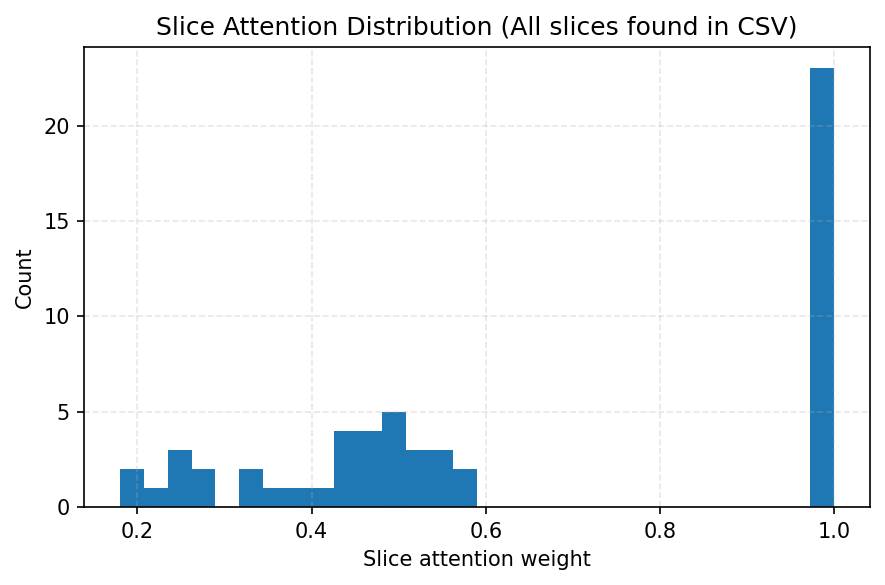

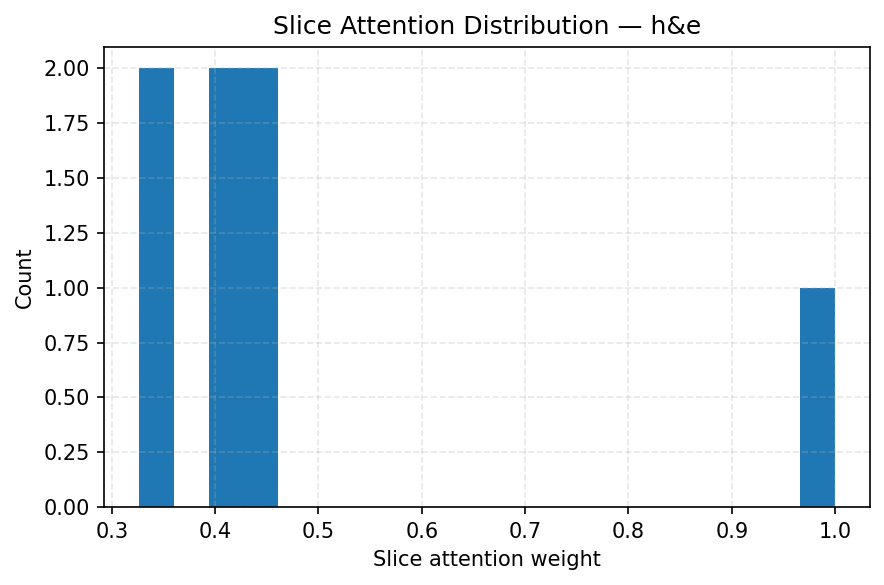

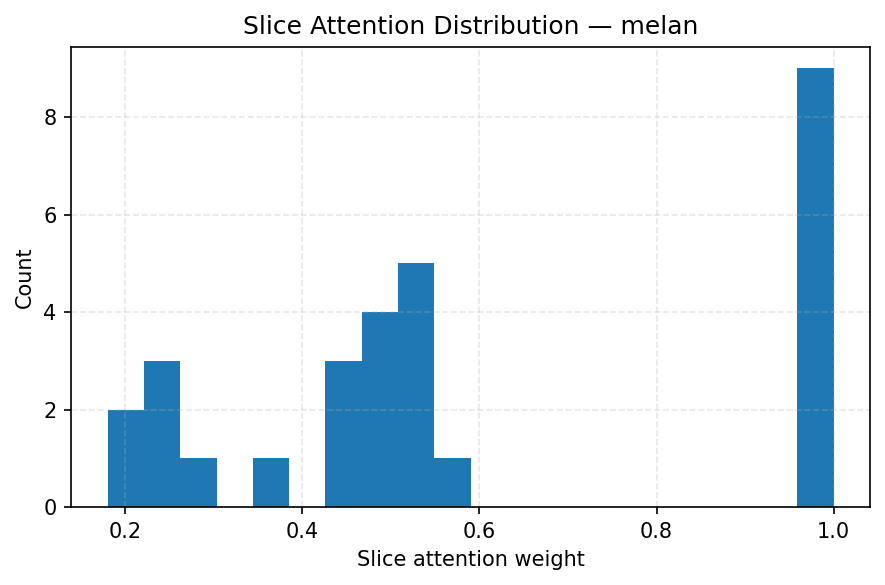

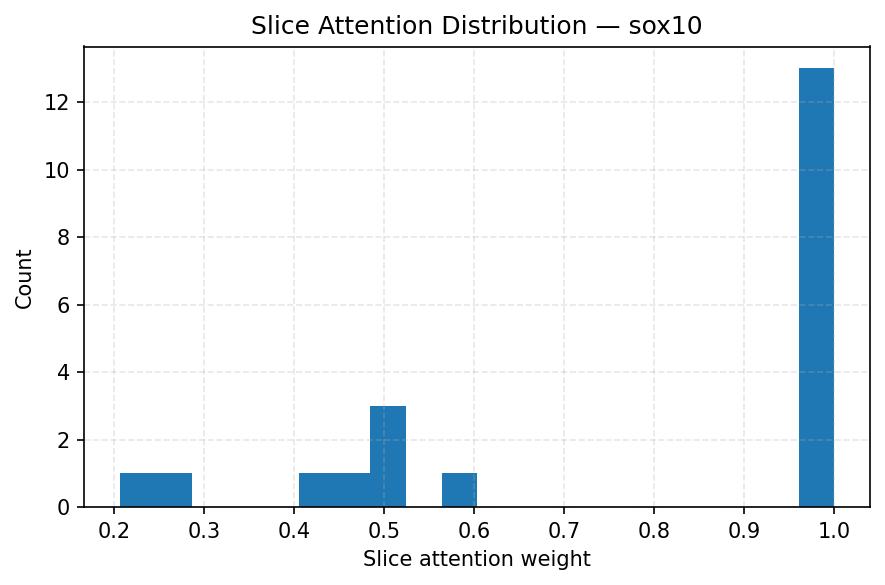

In [6]:
# SLICE ATTENTION DISTRIBUTION (from top_effective_patches_per_case_5.0pct.csv)

attn["case_id"] = pd.to_numeric(attn["case_id"], errors="coerce")
attn["slice_idx"] = pd.to_numeric(attn["slice_idx"], errors="coerce")
attn["slice_attn_weight"] = pd.to_numeric(attn["slice_attn_weight"], errors="coerce")
attn["stain"] = attn["stain"].astype(str).str.lower()

attn = attn.dropna(subset=["case_id", "stain", "slice_idx", "slice_attn_weight"]).copy()
attn["case_id"] = attn["case_id"].astype(int)
attn["slice_idx"] = attn["slice_idx"].astype(int)

# dedup to one row per slice
slice_df = (
    attn.drop_duplicates(subset=["case_id", "stain", "slice_idx"])
      .loc[:, ["case_id", "stain", "slice_idx", "slice_attn_weight"]]
      .copy()
)

print("\nUnique cases (slice df):", slice_df["case_id"].nunique())
print("Unique slices (dedup):", len(slice_df))
print("Slice attn min/median/max:",
      float(slice_df["slice_attn_weight"].min()),
      float(slice_df["slice_attn_weight"].median()),
      float(slice_df["slice_attn_weight"].max()))


plt.figure(figsize=(6,4), dpi=150)
plt.hist(slice_df["slice_attn_weight"].values, bins=30)
plt.xlabel("Slice attention weight")
plt.ylabel("Count")
plt.title("Slice Attention Distribution (All slices found in CSV)")
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

# ---- slice distribution by stain (separate)
for stain in sorted(slice_df["stain"].unique()):
    x = slice_df.loc[slice_df["stain"] == stain, "slice_attn_weight"].values
    plt.figure(figsize=(6,4), dpi=150)
    plt.hist(x, bins=20)
    plt.xlabel("Slice attention weight")
    plt.ylabel("Count")
    plt.title(f"Slice Attention Distribution — {stain}")
    plt.grid(alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()


In [7]:
# correctness
attn["correct"] = (attn["true_label"] == attn["pred_label"])

# columns to show
cols = ["case_id", "stain", "slice_idx", "patch_idx", "effective_weight"]

def show_top_low(name, mask, k=10):
    g = attn.loc[mask, cols].copy()
    print("\n" + "="*60)
    print(name, f"(n={len(g)})")
    print("="*60)

    if len(g) == 0:
        return

    high = g.sort_values("effective_weight", ascending=False).head(k)
    low  = g.sort_values("effective_weight", ascending=True).head(k)

    print("\nTop 10 HIGH attention patches (by effective_weight):")
    print(high.to_string(index=False))

    print("\nTop 10 LOW attention patches (by effective_weight):")
    print(low.to_string(index=False))


show_top_low("Correct Benign (true=0, pred=0)",
             (attn["correct"]) & (attn["true_label"] == 0))

show_top_low("Correct High-Grade (true=1, pred=1)",
             (attn["correct"]) & (attn["true_label"] == 1))





Correct Benign (true=0, pred=0) (n=167)

Top 10 HIGH attention patches (by effective_weight):
 case_id stain  slice_idx  patch_idx  effective_weight
      45 melan          0         12          0.039925
      45 melan          0         41          0.037612
      45 melan          0         11          0.035631
      45 melan          0         42          0.031058
      45 sox10          0          1          0.027889
      45 sox10          0         17          0.025698
    3026 melan          1          7          0.015446
    3026 melan          1         17          0.012731
    3026 melan          1         13          0.012425
    2025 melan          0         38          0.011882

Top 10 LOW attention patches (by effective_weight):
 case_id stain  slice_idx  patch_idx  effective_weight
      28 sox10          0         83          0.002789
      28 melan          0          3          0.002790
      28 sox10          0         22          0.002792
      28 melan          0  

In [8]:
show_top_low("Incorrect Benign (true=0, pred=1)",
             (~attn["correct"]) & (attn["true_label"] == 0))

show_top_low("Incorrect High-Grade (true=1, pred=0)",
             (~attn["correct"]) & (attn["true_label"] == 1))


Incorrect Benign (true=0, pred=1) (n=56)

Top 10 HIGH attention patches (by effective_weight):
 case_id stain  slice_idx  patch_idx  effective_weight
    3022 melan          0         69          0.016672
    3022 melan          0         55          0.013053
    3022 melan          0         75          0.010596
    3022 melan          0         57          0.009831
    3022 melan          0         49          0.009693
    3022 melan          0         76          0.009325
    3022 melan          0         61          0.009119
    3022 melan          0          9          0.009097
    3022 melan          0         13          0.007806
    3022 melan          0         90          0.007519

Top 10 LOW attention patches (by effective_weight):
 case_id stain  slice_idx  patch_idx  effective_weight
    2082   h&e          2         22          0.003445
    2082   h&e          0        105          0.003476
    2082   h&e          0         12          0.003530
    2082   h&e          2 